# Multiple Linear Regression – Multi-Channel Marketing Analysis

## Project Overview

This project investigates the impact of TV advertising, Radio advertising, Social Media advertising, and Influencer categories on Sales using Multiple Linear Regression.

The objectives are to:

- Evaluate relationships among marketing channels.
- Detect multicollinearity using correlation analysis and VIF.
- Build a Multiple Linear Regression model.
- Assess model performance using Adjusted R-squared and p-values.
- Validate regression assumptions through residual diagnostics.
- Provide business recommendations for marketing budget allocation.

In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from scipy import stats

## Data Loading and Initial Exploration

The dataset is loaded into a Pandas DataFrame for inspection. The exploration includes examining the dataset, its structure, variable types, and descriptive statistics.

In [31]:
df = pd.read_csv('marketing-sales-data.csv')

In [32]:
df.head()

,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


## Exploratory Data Analysis (EDA)

This section explores the dataset structure, identifies variable types, and checks for potential issues such as missing values, categorical variables that may require encoding before modeling.

In [33]:
df.info()
df.describe()
df.isnull().sum() 

<class 'pandas.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            572 non-null    str    
 1   Radio         572 non-null    float64
 2   Social Media  572 non-null    float64
 3   Influencer    572 non-null    str    
 4   Sales         572 non-null    float64
dtypes: float64(3), str(2)
memory usage: 22.5 KB


TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64

## Correlation Analysis

A correlation matrix is used to examine relationships among numerical variables and identify potential multicollinearity issues before model development.

In [34]:
df['TV'].head(10)

0       Low
1       Low
2      High
3    Medium
4      High
5       Low
6    Medium
7    Medium
8    Medium
9      High
Name: TV, dtype: str

In [35]:
df['TV'].unique()[:20]

<StringArray>
['Low', 'High', 'Medium']
Length: 3, dtype: str

In [36]:
print(df['Influencer'].unique())

<StringArray>
['Micro', 'Mega', 'Nano', 'Macro']
Length: 4, dtype: str


## Data Preprocessing

The TV advertising variable is encoded as an ordinal variable where:

- Low = 1
- Medium = 2
- High = 3

The Influencer variable is converted into dummy variables to make it suitable for regression analysis.

In [37]:
tv_mapping = {
    'Low': 1,
    'Medium': 2,
    'High': 3
}

df['TV_encoded'] = df['TV'].map(tv_mapping)


In [38]:
df = pd.get_dummies(
    df,
    columns=['Influencer'],
    drop_first=True
)

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   TV                572 non-null    str    
 1   Radio             572 non-null    float64
 2   Social Media      572 non-null    float64
 3   Sales             572 non-null    float64
 4   TV_encoded        572 non-null    int64  
 5   Influencer_Mega   572 non-null    bool   
 6   Influencer_Micro  572 non-null    bool   
 7   Influencer_Nano   572 non-null    bool   
dtypes: bool(3), float64(3), int64(1), str(1)
memory usage: 24.1 KB


In [40]:
df['Influencer_Mega'] = df['Influencer_Mega'].astype(int)
df['Influencer_Micro'] = df['Influencer_Micro'].astype(int)
df['Influencer_Nano'] = df['Influencer_Nano'].astype(int)

In [41]:
X = df[['Radio',
        'Social Media',
        'TV_encoded',
        'Influencer_Mega',
        'Influencer_Micro',
        'Influencer_Nano']]

y = df['Sales']

X = sm.add_constant(X)

In [42]:
X = X.astype(float)

print(X.dtypes)

const               float64
Radio               float64
Social Media        float64
TV_encoded          float64
Influencer_Mega     float64
Influencer_Micro    float64
Influencer_Nano     float64
dtype: object


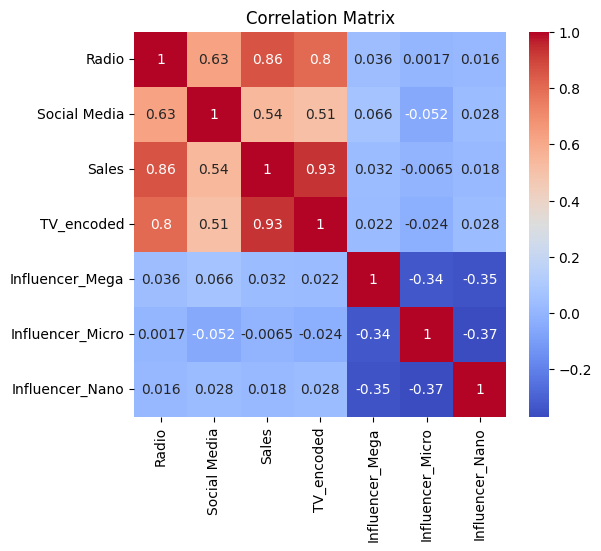

In [43]:
numeric_df = df.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')

plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

## Multiple Linear Regression Model

A Multiple Linear Regression model is fitted using TV advertising intensity, Radio advertising, Social Media advertising, and Influencer categories as predictors of Sales.

In [44]:
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     887.9
Date:                Wed, 17 Jun 2026   Prob (F-statistic):          7.41e-284
Time:                        13:19:44   Log-Likelihood:                -2713.7
No. Observations:                 572   AIC:                             5441.
Df Residuals:                     565   BIC:                             5472.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              -13.9135      3.760  

## Model Interpretation

The regression model achieved an R-squared value of 0.904 and an Adjusted R-squared value of 0.903, indicating that approximately 90.3% of the variation in Sales is explained by the predictors included in the model.

The overall model was statistically significant (p < 0.001), suggesting that the predictors collectively explain Sales variation effectively.

In [45]:
print(X.info())
print(X.head())

<class 'pandas.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   const             572 non-null    float64
 1   Radio             572 non-null    float64
 2   Social Media      572 non-null    float64
 3   TV_encoded        572 non-null    float64
 4   Influencer_Mega   572 non-null    float64
 5   Influencer_Micro  572 non-null    float64
 6   Influencer_Nano   572 non-null    float64
dtypes: float64(7)
memory usage: 31.4 KB
None
   const      Radio  Social Media  TV_encoded  Influencer_Mega  \
0    1.0   3.518070      2.293790         1.0              0.0   
1    1.0   7.756876      2.572287         1.0              1.0   
2    1.0  20.348988      1.227180         3.0              0.0   
3    1.0  20.108487      2.728374         2.0              1.0   
4    1.0  31.653200      7.776978         3.0              0.0   

   Influencer_Micro  Influencer_Nano  
0 

## Multicollinearity Assessment

Variance Inflation Factor (VIF) is calculated for all predictor variables. VIF values below 5 indicate that multicollinearity is not a significant concern.

In [46]:
vif = pd.DataFrame()

vif["Variable"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif)

           Variable        VIF
0             const  10.331824
1             Radio   3.467595
2      Social Media   1.668618
3        TV_encoded   2.827469
4   Influencer_Mega   1.589539
5  Influencer_Micro   1.618005
6   Influencer_Nano   1.626443


## Interpretation

All predictor VIF values are below 5, indicating no evidence of problematic multicollinearity. Therefore, all variables can remain in the model without causing instability in coefficient estimates.

In [47]:
X_reduced = df[['Radio', 'TV_encoded']]

X_reduced = sm.add_constant(X_reduced)

model_reduced = sm.OLS(y, X_reduced).fit()

print(model_reduced.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     2676.
Date:                Wed, 17 Jun 2026   Prob (F-statistic):          3.70e-290
Time:                        13:19:44   Log-Likelihood:                -2714.3
No. Observations:                 572   AIC:                             5435.
Df Residuals:                     569   BIC:                             5448.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -12.3902      3.066     -4.041      0.0

In [48]:
print("Full Model Adj R²:", model.rsquared_adj)
print("Reduced Model Adj R²:", model_reduced.rsquared_adj)

Full Model Adj R²: 0.9030914918040578
Reduced Model Adj R²: 0.9035752097622348


## Reduced Model Interpretation

The reduced model was compared to the full model using Adjusted R-squared.

If the Adjusted R-squared remains similar to that of the full model, the reduced model is preferred because it achieves comparable predictive performance with fewer variables, making it more easier to interpret.

## Regression Assumption Testing

Regression assumptions were evaluated using residual diagnostic plots. Specifically:

- Residuals vs Fitted plot was used to assess linearity and homoscedasticity.
- Q-Q plot was used to assess normality.
- Residual distribution histogram was used to examine the shape of residuals.

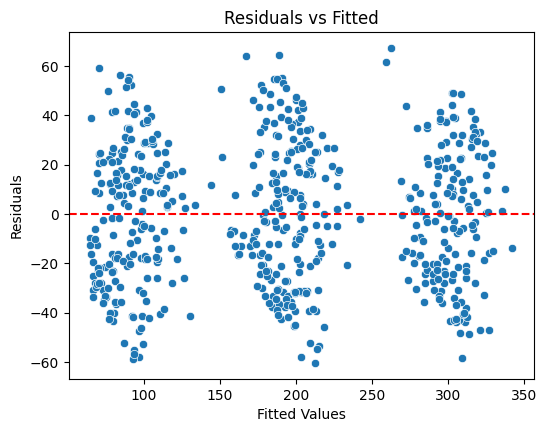

In [49]:
predictions = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(6,4.5))
sns.scatterplot(x=predictions, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")

plt.savefig('residual_vs_fitted.png', bbox_inches='tight')
plt.show()

### Linearity and Homoscedasticity

The residuals appear randomly distributed around zero with no obvious systematic pattern. This suggests that the assumptions of linearity and constant variance are reasonably satisfied.

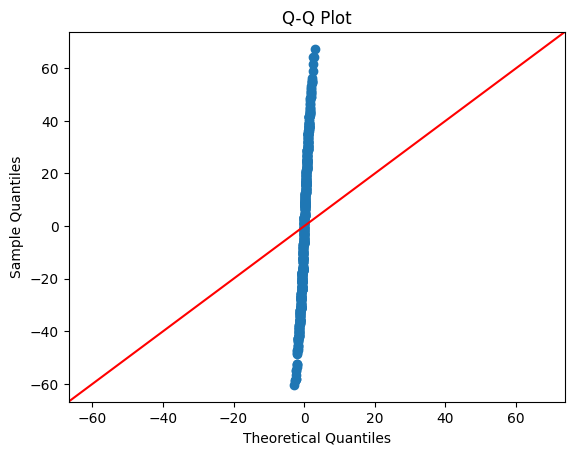

In [50]:
sm.qqplot(residuals, line='45')
plt.title("Q-Q Plot")

plt.savefig('qq_plot.png', bbox_inches='tight')
plt.show()

### Normality Assessment

The Q-Q plot indicates that residuals approximately follow a normal distribution. Minor deviations are present but are not severe enough to invalidate the model.

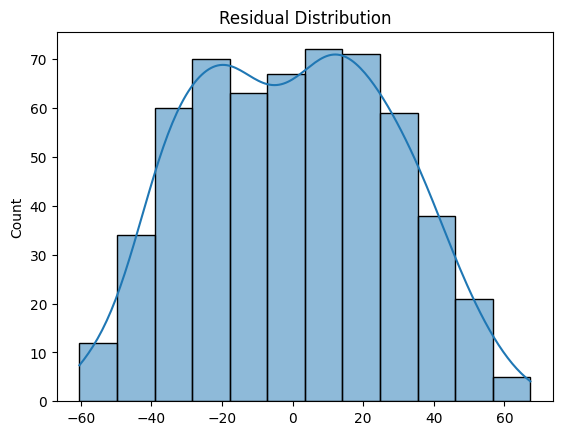

In [51]:
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")

plt.savefig('residual_distribution.png', bbox_inches='tight')
plt.show()

### Residual Distribution

The residual histogram exhibits an approximately bell-shaped distribution centered around zero, providing additional support for the normality assumption.

# Business Recommendation

Based on the analysis:

- TV advertising intensity is a significant predictor of Sales.
- Radio advertising expenditure is a significant predictor of Sales.
- Social Media advertising and Influencer categories did not demonstrate statistically significant effects.

Therefore, marketing managers should prioritize budget allocation toward TV and Radio advertising channels while reassessing the effectiveness of Social Media and Influencer campaigns.

# Conclusion

The Multiple Linear Regression model successfully explained approximately 90.3% of the variation in Sales. Diagnostic testing confirmed that model assumptions were reasonably satisfied, and multicollinearity was not a concern. The results support data-driven marketing budget allocation decisions focused primarily on TV and Radio advertising.